#Image Classifictaion

##Setup

###Installs

###Imports

In [228]:
import tensorflow as tf
import matplotlib.pyplot as plt
import random
import numpy as np
from datasets import Dataset, load_dataset, concatenate_datasets, DatasetDict
from transformers import set_seed
from torchvision import transforms
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import f1_score

##Task 1(30 points):Simple Image Classification Models

###Part 1 (10 points): This step involves downloading, preparing, and visualizing your dataset. Create a convolutional base using a common pattern: a stack of Conv and MaxPooling layers. Depending on the problem and the dataset you must decide what pattern you want to use (i.e., how many Conv layers and how many pooling layers). Please describe why you chose a particular pattern. Add the final dense layer(s). Compile and train the model. Report the final evaluation and describe the metrics.


####Downloading DataSet

In [229]:
dataset = load_dataset("food101", split="train[:5%]")  # small for testing

unique_label_ids = list(set(dataset["label"]))
print(unique_label_ids)

swap_map = {6:5, 10:4, 79:3, 81:2, 20:1, 53:0}

def swap_labels(example):
    example["label"] = swap_map[example["label"]]
    return example


dataset = dataset.train_test_split(test_size=0.2, seed=42)
train_data = dataset["train"]
test_data = dataset["test"]

print("Train size:", len(train_data))
print("Test size:", len(test_data))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00008.parquet:   0%|          | 0.00/490M [00:00<?, ?B/s]

data/train-00001-of-00008.parquet:   0%|          | 0.00/464M [00:00<?, ?B/s]

data/train-00002-of-00008.parquet:   0%|          | 0.00/472M [00:00<?, ?B/s]

...

data/validation-00001-of-00003.parquet:   0%|          | 0.00/413M [00:00<?, ?B/s]

data/validation-00002-of-00003.parquet:   0%|          | 0.00/426M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/75750 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/25250 [00:00<?, ? examples/s]

[6, 10, 79, 81, 20, 53]
Train size: 3030
Test size: 758


In [230]:
unique_label_ids = list(set(test_data["label"]))
print(unique_label_ids)

[6, 10, 79, 81, 20, 53]


In [231]:
Training_Data = dataset["train"]
Testing_Data = dataset["test"]

####Preparing Data

In [232]:
image_size = (224, 224)

In [233]:
Training_Data = train_data.map(swap_labels)
Testing_Data = test_data.map(swap_labels)

Map:   0%|          | 0/3030 [00:00<?, ? examples/s]

Map:   0%|          | 0/758 [00:00<?, ? examples/s]

In [234]:
Training_Data = Training_Data.shuffle(seed=42).select(range(300))
Testing_Data = Training_Data.shuffle(seed=42).select(range(50))

In [235]:
def preprocess_batch(batch, img_size=(224, 224)):
    batch["image"] = np.stack([
        np.array(img.resize(img_size), dtype=np.float32) / 255.0
        for img in batch["image"]
    ])
    batch["label"] = np.array([to_categorical(l, num_classes=6) for l in batch["label"]])
    return batch

Training_Data_Arr = Training_Data.map(preprocess_batch, batched=True, batch_size=32)
Testing_Data_Arr = Testing_Data.map(preprocess_batch, batched=True, batch_size=32)


Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Map:   0%|          | 0/50 [00:00<?, ? examples/s]

In [236]:
X_train = np.stack(Training_Data_Arr["image"])
y_train = np.stack(Training_Data_Arr["label"])

X_test = np.stack(Testing_Data_Arr["image"])
y_test = np.stack(Testing_Data_Arr["label"])

In [237]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (300, 224, 224, 3)
y_train: (300, 6)
X_test: (50, 224, 224, 3)
y_test: (50, 6)


####Visualizing DataSet

In [238]:
print("Dataset Structure\n")
print(Training_Data_Arr)

Dataset Structure

Dataset({
    features: ['image', 'label'],
    num_rows: 300
})


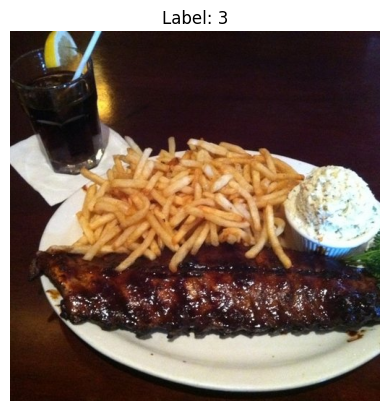

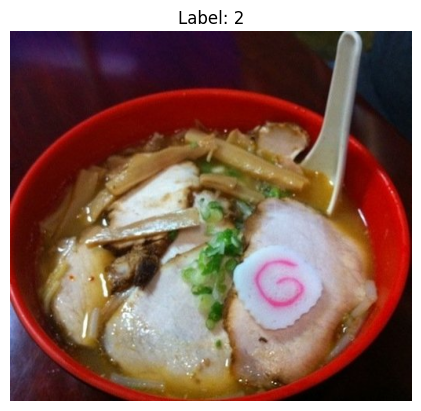

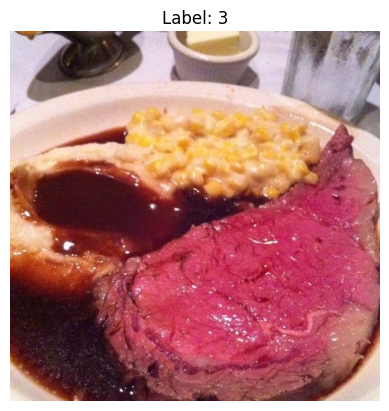

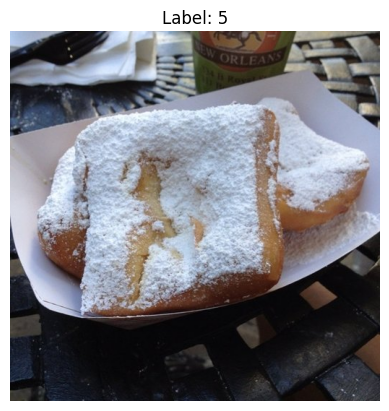

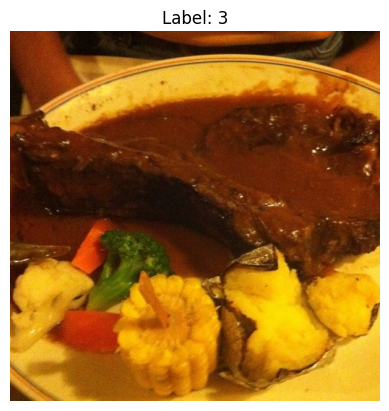

In [239]:
for i in range(5):
    example = Training_Data[random.randint(0, len(Training_Data)-1)]

    plt.imshow(example["image"])
    plt.title(f"Label: {example['label']}")
    plt.axis("off")
    plt.show()

####Compiling Model

In [240]:
image_shape = (224, 224, 3)

In [241]:
imageClassifier = tf.keras.Sequential([
    tf.keras.Input(shape=(image_shape)),    #takes in image

    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),#Goes over image shrinking it only keeping important features.
    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),

    tf.keras.layers.Flatten(), # flattens to a 1d matrix for dense layers
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(6, activation="softmax") # 100 hundred diffrent foods
])


Model Layout Explination


---


I chose to do 2 conv2d and maxpools to shrink image down 9x since the images are quite large. I used 3x3 for Conv2D as that is usialy the standard used for. While Max pool is usialy done using 2X2 since our images are quite large I think it is fitting to shrink them down more and sacrifice a bit of detail. Oh and I had a Maxpool follow each Conv2d as that is the best for keeping only important details.

In [242]:
imageClassifier.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

####Training Model

In [243]:
history = imageClassifier.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.1967 - loss: 2.0918 - val_accuracy: 0.4000 - val_loss: 1.6932
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.3400 - loss: 1.6014 - val_accuracy: 0.5400 - val_loss: 1.2980
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.4967 - loss: 1.2719 - val_accuracy: 0.7400 - val_loss: 0.8631
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.6900 - loss: 0.9965 - val_accuracy: 0.7000 - val_loss: 0.7317
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.7433 - loss: 0.7783 - val_accuracy: 0.9000 - val_loss: 0.4700
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.8200 - loss: 0.5080 - val_accuracy: 0.9600 - val_loss: 0.2737
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.9367 - loss: 0.3015 - val_accuracy: 0.9800 - val_loss: 0.1196
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.9733 - loss: 0.1358 - val_accuracy: 1.0000 - val_loss:

####Evaluating Model

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 254ms/step


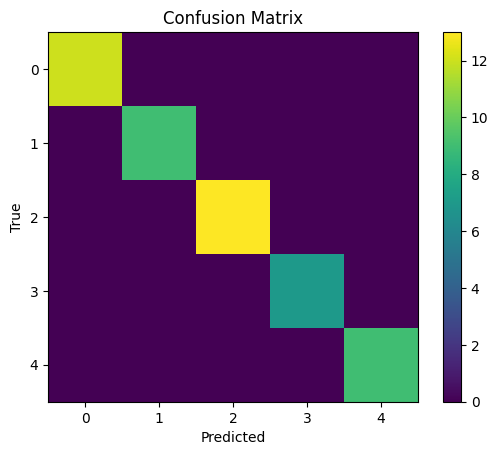

In [244]:
import numpy as np
from sklearn.metrics import confusion_matrix

y_pred = imageClassifier.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

if len(y_test.shape) > 1:
    y_true = np.argmax(y_test, axis=1)
else:
    y_true = y_test

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.show()

In [245]:
f1 = f1_score(y_true, y_pred_classes, average="macro")
print("F1 Score (macro):", f1) # average f1 score

F1 Score (macro): 1.0


The model preforms the best on burgers and soup.  However it struggled mostly on guessing weather something was steak. This is likley due to the fact that the photos with steak often had other foods ocompianing it on the side.

###Part 2 (10 points): The following models are widely used for transfer learning because of their performance and architectural innovations:
1. VGG (e.g., VGG16 or VGG19).
2. GoogLeNet (e.g., InceptionV3).
3. Residual Network (e.g., ResNet50).
4. MobileNet (e.g., MobileNetV2)

Choose any one of the above models to perform the classification task you did in Part 1.
Evaluate the results using the same metrics as in Part 1. Are there any differences? Why
or why not? Describe in detail.

####Compiling Model

In [246]:
import tensorflow as tf
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.applications.inception_v3 import preprocess_input
from tensorflow.keras.applications import VGG16

vgg_models = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))

for layer in vgg_models.layers:
    layer.trainable = False

#fit model for same classification
x = vgg_models.output
x = GlobalAveragePooling2D()(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(6, activation='softmax')(x)

vgg_model = Model(inputs=vgg_models.input, outputs=output)

vgg_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = vgg_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=3
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/3
10/10 ━━━━━━━━━━━━━━━━━━━━ 142s 14s/step - accuracy: 0.2200 - loss: 1.8610 - val_accuracy: 0.3000 - val_loss: 1.6381
Epoch 2/3
10/10 ━━━━━━━━━━━━━━━━━━━━ 141s 14s/step - accuracy: 0.2900 - loss: 1.7077 - val_accuracy: 0.4600 - val_loss: 1.5171
Epoch 3/3
10/10 ━━━━━━━━━━━━━━━━━━━━ 142s 14s/step - accuracy: 0.3367 - loss: 1.5664 - val_accuracy: 0.6200 - val_loss: 1.4125


####Evaluating Model

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 197ms/step


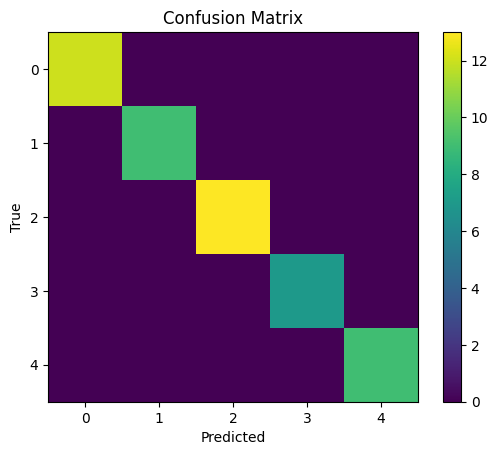

In [247]:
import numpy as np
from sklearn.metrics import confusion_matrix

y_pred = imageClassifier.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

if len(y_test.shape) > 1:
    y_true = np.argmax(y_test, axis=1)
else:
    y_true = y_test

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.show()

In [248]:
f1 = f1_score(y_true, y_pred_classes, average="macro")
print("F1 Score (macro):", f1) # average f1 score

F1 Score (macro): 1.0


Accuracy Is perfect and with data augmentation however the model learns quicker reaching prefrection in only 7 epocks

###Part 3 (10 points): Use data augmentation to increase the diversity of your dataset by applying random transformations such as image rotation (you can use any other technique as well). Repeat the process from part 1 with this augmented data. Did you observe any difference in results? Why or why not?

####Data Agumentation

In [249]:
def random_augment(X):
    X_aug = []

    for img in X:
        img = tf.convert_to_tensor(img)

        if np.random.rand() > 0.25:
          img = tf.image.rot90(img, k=np.random.randint(0, 4))

        if np.random.rand() > 0.25:
            img = tf.image.flip_left_right(img)

        X_aug.append(img.numpy())

    return np.array(X_aug)

X_aug_train = random_augment(X_train)
X_aug_test = random_augment(X_test)

####Model Results

In [250]:
history = imageClassifier.fit(X_aug_train, y_train, epochs=10, validation_data=(X_aug_test, y_test))

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.5200 - loss: 1.5309 - val_accuracy: 0.5000 - val_loss: 1.1704
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.7633 - loss: 0.8305 - val_accuracy: 0.7800 - val_loss: 0.7132
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.8833 - loss: 0.3742 - val_accuracy: 0.7400 - val_loss: 0.7474
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.9533 - loss: 0.1812 - val_accuracy: 0.7000 - val_loss: 0.7697
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.9900 - loss: 0.0724 - val_accuracy: 0.7600 - val_loss: 0.8481
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.9967 - loss: 0.0443 - val_accuracy: 0.8200 - val_loss: 0.7965
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 1.0000 - loss: 0.0189 - val_accuracy: 0.7000 - val_loss: 0.8711
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 1.0000 - loss: 0.0094 - val_accuracy: 0.7600 - val_loss:

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 187ms/step


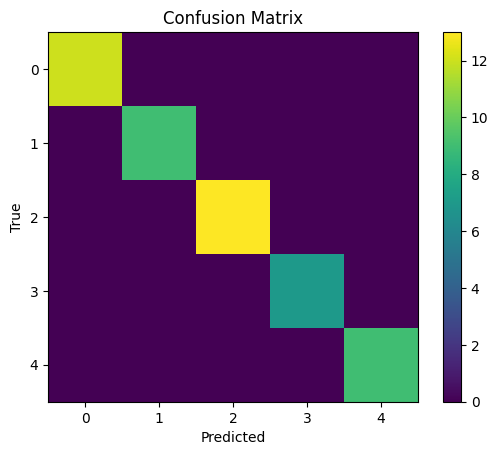

In [251]:
y_pred = imageClassifier.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

if len(y_test.shape) > 1:
    y_true = np.argmax(y_test, axis=1)
else:
    y_true = y_test

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.show()


Accuracy decreases to only 60% this is likley due to the fact that the augmentations like routate 90deg doesnt genralize to the test data instead just causing more stark overfitting.

##Task 2(15 points)

####Part 1 (7 points): Variational Autoencoder (VAE): Here is a complete implementation of a VAE in TensorFlow: https://www.tensorflow.org/tutorials/generative/cvae PyTorch implementation is fine too. Following these steps try generating images using the same encoder-decoder architecture using a different Image dataset (other than MNIST). Projects in Machine Learning and AI (RPI Spring 2026)

In [252]:
from IPython import display

import glob
import imageio
import matplotlib.pyplot as plt
import numpy as np
import PIL
import tensorflow as tf
import tensorflow_probability as tfp
import time
from tensorflow.keras.datasets import cifar10

In [253]:
(train_images, _), (test_images, _) = cifar10.load_data()

In [254]:
def preprocess_images(images):
    images = images.astype('float32') / 255.0   # normalize
    return images

train_images = preprocess_images(train_images)
test_images = preprocess_images(test_images)

In [255]:
train_size = 60000
batch_size = 32
test_size = 10000

In [256]:
train_dataset = (tf.data.Dataset.from_tensor_slices(train_images)
                 .shuffle(train_size).batch(batch_size))
test_dataset = (tf.data.Dataset.from_tensor_slices(test_images)
                .shuffle(test_size).batch(batch_size))

In [257]:
class CVAE(tf.keras.Model):
  """Convolutional variational autoencoder."""

  def __init__(self, latent_dim):
    super(CVAE, self).__init__()
    self.latent_dim = latent_dim
    self.encoder = tf.keras.Sequential(
        [
            tf.keras.layers.InputLayer(input_shape=(32, 32, 3)),
            tf.keras.layers.Conv2D(
                filters=32, kernel_size=3, strides=(2, 2), activation='relu'),
            tf.keras.layers.Conv2D(
                filters=64, kernel_size=3, strides=(2, 2), activation='relu'),
            tf.keras.layers.Flatten(),
            # No activation
            tf.keras.layers.Dense(latent_dim + latent_dim),
        ]
    )

    self.decoder = tf.keras.Sequential(
        [
            tf.keras.layers.InputLayer(input_shape=(latent_dim,)),
            tf.keras.layers.Dense(units=8*8*32, activation=tf.nn.relu),
            tf.keras.layers.Reshape(target_shape=(8, 8, 32)),
            tf.keras.layers.Conv2DTranspose(
                filters=64, kernel_size=3, strides=2, padding='same',
                activation='relu'),
            tf.keras.layers.Conv2DTranspose(
                filters=32, kernel_size=3, strides=2, padding='same',
                activation='relu'),
            # No activation
            tf.keras.layers.Conv2DTranspose(
                filters=3, kernel_size=3, strides=1, padding='same'),
        ]
    )

  @tf.function
  def sample(self, eps=None):
    if eps is None:
      eps = tf.random.normal(shape=(100, self.latent_dim))
    return self.decode(eps, apply_sigmoid=True)

  def encode(self, x):
    mean, logvar = tf.split(self.encoder(x), num_or_size_splits=2, axis=1)
    return mean, logvar

  def reparameterize(self, mean, logvar):
    eps = tf.random.normal(shape=mean.shape)
    return eps * tf.exp(logvar * .5) + mean

  def decode(self, z, apply_sigmoid=False):
    logits = self.decoder(z)
    if apply_sigmoid:
      probs = tf.sigmoid(logits)
      return probs
    return logits

In [258]:
optimizer = tf.keras.optimizers.Adam(1e-4)


def log_normal_pdf(sample, mean, logvar, raxis=1):
  log2pi = tf.math.log(2. * np.pi)
  return tf.reduce_sum(
      -.5 * ((sample - mean) ** 2. * tf.exp(-logvar) + logvar + log2pi),
      axis=raxis)


def compute_loss(model, x):
  mean, logvar = model.encode(x)
  z = model.reparameterize(mean, logvar)
  x_logit = model.decode(z)
  cross_ent = tf.nn.sigmoid_cross_entropy_with_logits(logits=x_logit, labels=x)
  logpx_z = -tf.reduce_sum(cross_ent, axis=[1, 2, 3])
  logpz = log_normal_pdf(z, 0., 0.)
  logqz_x = log_normal_pdf(z, mean, logvar)
  return -tf.reduce_mean(logpx_z + logpz - logqz_x)


@tf.function
def train_step(model, x, optimizer):
  """Executes one training step and returns the loss.

  This function computes the loss and gradients, and uses the latter to
  update the model's parameters.
  """
  with tf.GradientTape() as tape:
    loss = compute_loss(model, x)
  gradients = tape.gradient(loss, model.trainable_variables)
  optimizer.apply_gradients(zip(gradients, model.trainable_variables))

In [259]:
epochs = 10
# set the dimensionality of the latent space to a plane for visualization later
latent_dim = 2
num_examples_to_generate = 16

# keeping the random vector constant for generation (prediction) so
# it will be easier to see the improvement.
random_vector_for_generation = tf.random.normal(
    shape=[num_examples_to_generate, latent_dim])
model = CVAE(latent_dim)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [260]:
def generate_and_save_images(model, epoch, test_sample):
  mean, logvar = model.encode(test_sample)
  z = model.reparameterize(mean, logvar)
  predictions = model.sample(z)
  fig = plt.figure(figsize=(4, 4))

  for i in range(predictions.shape[0]):
    plt.subplot(4, 4, i + 1)
    plt.imshow(predictions[i, :, :, 0])
    plt.axis('off')

  # tight_layout minimizes the overlap between 2 sub-plots
  plt.savefig('image_at_epoch_{:04d}.png'.format(epoch))
  plt.show()

In [261]:
# Pick a sample of the test set for generating output images
assert batch_size >= num_examples_to_generate
for test_batch in test_dataset.take(1):
  test_sample = test_batch[0:num_examples_to_generate, :, :, :]

Epoch: 10, Test set ELBO: -1960.7491455078125, time elapse for current epoch: 60.06881237030029


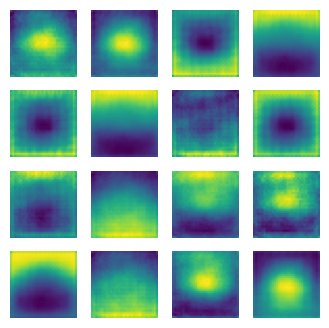

In [262]:
generate_and_save_images(model, 0, test_sample)

for epoch in range(1, epochs + 1):
  start_time = time.time()
  for train_x in train_dataset:
    train_step(model, train_x, optimizer)
  end_time = time.time()

  loss = tf.keras.metrics.Mean()
  for test_x in test_dataset:
    loss(compute_loss(model, test_x))
  elbo = -loss.result()
  display.clear_output(wait=False)
  print('Epoch: {}, Test set ELBO: {}, time elapse for current epoch: {}'
        .format(epoch, elbo, end_time - start_time))
  generate_and_save_images(model, epoch, test_sample)

####Part 2 (8 points): Generative Adversarial Networks (GANs): Repeat part 1 (use same dataset) and implement a GAN model to generate high quality synthetic images. You may follow steps outlined here: https://www.tensorflow.org/tutorials/generative/dcgan


In [263]:
import glob
import imageio
import matplotlib.pyplot as plt
import numpy as np
import os
import PIL
from tensorflow.keras import layers
import time

from IPython import display

In [264]:
(train_images, train_labels), (_, _) = cifar10.load_data()

In [265]:
train_images = train_images.reshape(train_images.shape[0], 32, 32, 3).astype('float32')
train_images = (train_images - 127.5) / 127.5  # Normalize the images to [-1, 1]

In [266]:
BUFFER_SIZE = 60000
BATCH_SIZE = 256

In [267]:
# Batch and shuffle the data
train_dataset = tf.data.Dataset.from_tensor_slices(train_images).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

In [268]:
def make_generator_model():
    model = tf.keras.Sequential()
    model.add(layers.Dense(8*8*256, use_bias=False, input_shape=(100,)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Reshape((8, 8, 256)))
    assert model.output_shape == (None, 8, 8, 256)

    model.add(layers.Conv2DTranspose(128, (5,5), strides=(1,1), padding='same', use_bias=False))
    assert model.output_shape == (None, 8, 8, 128)
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(64, (5,5), strides=(2,2), padding='same', use_bias=False))
    assert model.output_shape == (None, 16, 16, 64)
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(3, (5,5), strides=(2,2), padding='same', use_bias=False, activation='tanh'))
    assert model.output_shape == (None, 32, 32, 3)

    return model

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


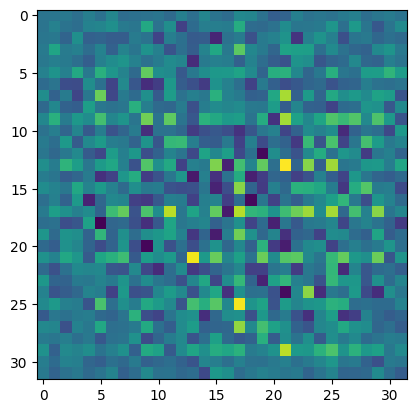

In [269]:
generator = make_generator_model()

noise = tf.random.normal([1, 100])
generated_image = generator(noise, training=False)

plt.imshow(generated_image[0, :, :, 0])

In [270]:
def make_discriminator_model():
    model = tf.keras.Sequential()
    model.add(layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same',
                                     input_shape=[32, 32, 3]))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1))

    return model

In [271]:
discriminator = make_discriminator_model()
decision = discriminator(generated_image)
print (decision)

tf.Tensor([[0.00298247]], shape=(1, 1), dtype=float32)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [272]:
# This method returns a helper function to compute cross entropy loss
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

In [273]:
def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    total_loss = real_loss + fake_loss
    return total_loss

In [274]:
def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

In [275]:
generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

In [276]:
checkpoint_dir = './training_checkpoints'
checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt")
checkpoint = tf.train.Checkpoint(generator_optimizer=generator_optimizer,
                                 discriminator_optimizer=discriminator_optimizer,
                                 generator=generator,
                                 discriminator=discriminator)

In [277]:
EPOCHS = 50
noise_dim = 100
num_examples_to_generate = 16

# You will reuse this seed overtime (so it's easier)
# to visualize progress in the animated GIF)
seed = tf.random.normal([num_examples_to_generate, noise_dim])

In [278]:
# Notice the use of `tf.function`
# This annotation causes the function to be "compiled".
@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, noise_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
      generated_images = generator(noise, training=True)

      real_output = discriminator(images, training=True)
      fake_output = discriminator(generated_images, training=True)

      gen_loss = generator_loss(fake_output)
      disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

In [279]:
def train(dataset, epochs):
  for epoch in range(epochs):
    start = time.time()

    for image_batch in dataset:
      train_step(image_batch)

    # Produce images for the GIF as you go
    display.clear_output(wait=True)
    generate_and_save_images(generator,
                             epoch + 1,
                             seed)

    # Save the model every 15 epochs
    if (epoch + 1) % 15 == 0:
      checkpoint.save(file_prefix = checkpoint_prefix)

    print ('Time for epoch {} is {} sec'.format(epoch + 1, time.time()-start))

  # Generate after the final epoch
  display.clear_output(wait=True)
  generate_and_save_images(generator,
                           epochs,
                           seed)

In [280]:
def generate_and_save_images(model, epoch, test_input):
  # Notice `training` is set to False.
  # This is so all layers run in inference mode (batchnorm).
  predictions = model(test_input, training=False)

  fig = plt.figure(figsize=(4, 4))

  for i in range(predictions.shape[0]):
      plt.subplot(4, 4, i+1)
      plt.imshow(predictions[i, :, :, 0] * 127.5 + 127.5)
      plt.axis('off')

  plt.savefig('image_at_epoch_{:04d}.png'.format(epoch))
  plt.show()

In [281]:
train(train_dataset, 3)

KeyboardInterrupt: 

##Task 3 (55 points) NLP and Attention Mechanism

###Part 1 (10 points): Implement the scaled dot-product attention as discussed in class (lecture 10) from scratch (use NumPy and pandas only, no deep learning libraries are allowed for this step).

In [ ]:
def sdpa(A, B, C, mask=None):
    if A.ndim == 1:
      A = A.reshape(1, -1)
    row_A = A.shape[1]

    scores = np.dot(A, B.T) / np.sqrt(row_A)

    if mask is not None:
        scores = np.where(mask == 0, -1e9, scores)

    exp_scores = np.exp(scores - np.max(scores, axis=-1, keepdims=True))
    a_weights = exp_scores / np.sum(exp_scores, axis=-1, keepdims=True)
    output = np.dot(a_weights, C)
    return output, a_weights

Q = np.random.rand(3, 4)
K = np.random.rand(3, 4)
V = np.random.rand(3, 5)

output, a_weights = sdpa(Q, K, V)
print("Output Vector:\n", output)
print("A_Weights:\n", a_weights)

###Part 2 (10 points): Pick any encoder-decoder seq2seq model (as discussed in class) and integrate the scaled dot-product attention in the encoder architecture. You may come up with your own technique of integration or adopt one from literature. Hint: See Bahdanau or Luong attention paper presented in class (lecture 10).

In [289]:
def rnn_encoder(X, size):
    lenSeq, input_dim = X.shape
    Wieghtxh = np.random.randn(input_dim, size) * 0.1
    Wieghthh = np.random.randn(size, size) * 0.1
    h = np.zeros((size,))
    states = []
    for t in range(lenSeq):
        h = np.tanh(X[t] @ Wieghtxh + h @ Wieghthh)
        states.append(h.copy())
    return np.array(states), Wieghtxh, Wieghthh

def rnn_decoder_step(Y_prev, encoder_hidden_states):
    size = encoder_hidden_states.shape[1]
    Wieghthd = np.random.randn(size, size) * 0.1
    hidden_state_t = np.tanh(Y_prev @ Wieghthd) ## get hiden state
    context, attn_weights = sdpa(hidden_state_t, encoder_hidden_states, encoder_hidden_states)
    combined = np.concatenate([hidden_state_t, context.flatten()])

    output = np.random.randn(combined.shape[0], size)
    y_pred = np.tanh(combined @ output) ## decoder predictions

    return y_pred, hidden_state_t, attn_weights

In [ ]:
X = np.random.rand(5, 6)

encoder_hidden_states = rnn_encoder(X, size=8)
print("Encoder hidden states shape:", encoder_hidden_states.shape)

Y_prev = np.zeros(8)
y_pred, decoder_hidden, attn_weights = rnn_decoder_step(Y_prev, encoder_hidden_states)

print("\nDecoder Output (y_pred):\n", y_pred)
print("\nDecoder Hidden State (h_t):\n", decoder_hidden)
print("\nAttention Weights:\n", attn_weights)

###Part 3 (5 points): Pick any public dataset of your choice (use a small-scale dataset like a subset of the Tatoeba or Multi30k dataset) for machine translation task. Train your model from Part 2 for the machine translation task. Evaluate test set by reporting the BLEU Score.

In [282]:
data = [
    ("I am happy", "Je suis heureux"),
    ("How are you?", "Comment ça va ?"),
    ("I love you", "Je t'aime"),
    ("Good morning", "Bonjour"),
    ("Thank you", "Merci"),
    ("See you later", "À plus tard"),
    ("What is your name?", "Comment tu t'appelles ?"),
    ("I am hungry", "J'ai faim"),
    ("I am tired", "Je suis fatigué"),
    ("Where is the bathroom?", "Où sont les toilettes ?"),
    ("I like apples", "J'aime les pommes"),
    ("Do you speak English?", "Parlez-vous anglais ?"),
    ("I need help", "J'ai besoin d'aide"),
    ("I am sorry", "Je suis désolé"),
    ("Good night", "Bonne nuit"),
    ("How old are you?", "Quel âge as-tu ?"),
    ("I don't understand", "Je ne comprends pas"),
    ("I am learning French", "J'apprends le français"),
    ("What time is it?", "Quelle heure est-il ?"),
    ("Have a nice day", "Bonne journée"),
    ('I not am happy', 'Je suis heureux'),
('How are you?', 'Comment ça va ?'),
('I love you', "Je t'aime"),
('Good morning', 'Bonjour'),
('Thank you', 'Merci'),
('See you later', 'À plus tard'),
('What is your name?', "Comment tu t'appelles ?"),
('We really am hungry', "J'ai faim"),
('I a little am tired', 'Je suis fatigué'),
('Where is the bathroom?', 'Où sont les toilettes ?'),
('You a little like apples', "J'aime les pommes"),
('Do you speak English?', 'Parlez-vous anglais ?'),
('You need help', "J'ai besoin d'aide"),
('I a little am sorry', 'Je suis désolé'),
('Good night', 'Bonne nuit'),
('How old are you?', 'Quel âge as-tu ?'),
("We don't understand", 'Je ne comprends pas'),
('We a little am learning French', "J'apprends le français"),
('What time is it?', 'Quelle heure est-il ?'),
('Have a nice day', 'Bonne journée'),
('We not am happy', 'Je suis heureux'),
('How are you?', 'Comment ça va ?'),
('I love you', "Je t'aime"),
('Good morning', 'Bonjour'),
('Thank you', 'Merci'),
('See you later', 'À plus tard'),
('What is your name?', "Comment tu t'appelles ?"),
('You really am hungry', "J'ai faim"),
('You a little am tired', 'Je suis fatigué'),
('Where is the bathroom?', 'Où sont les toilettes ?'),
('You very like apples', "J'aime les pommes"),
('Do you speak English?', 'Parlez-vous anglais ?'),
('We need help', "J'ai besoin d'aide"),
('I really am sorry', 'Je suis désolé'),
('Good night', 'Bonne nuit'),
('How old are you?', 'Quel âge as-tu ?'),
("You don't understand", 'Je ne comprends pas'),
('You really am learning French', "J'apprends le français"),
('What time is it?', 'Quelle heure est-il ?'),
('Have a nice day', 'Bonne journée'),
('You really am happy', 'Je suis heureux'),
('How are you?', 'Comment ça va ?'),
('You love you', "Je t'aime"),
('Good morning', 'Bonjour'),
('Thank you', 'Merci'),
('See you later', 'À plus tard'),
('What is your name?', "Comment tu t'appelles ?"),
('You really am hungry', "J'ai faim"),
('I not am tired', 'Je suis fatigué'),
('Where is the bathroom?', 'Où sont les toilettes ?'),
('I really like apples', "J'aime les pommes"),
('Do you speak English?', 'Parlez-vous anglais ?'),
('You need help', "J'ai besoin d'aide"),
('I very am sorry', 'Je suis désolé'),
('Good night', 'Bonne nuit'),
('How old are you?', 'Quel âge as-tu ?'),
("I don't understand", 'Je ne comprends pas'),
('I not am learning French', "J'apprends le français"),
('What time is it?', 'Quelle heure est-il ?'),
('Have a nice day', 'Bonne journée'),
('We not am happy', 'Je suis heureux'),
('How are you?', 'Comment ça va ?'),
('I love you', "Je t'aime"),
('Good morning', 'Bonjour'),
('Thank you', 'Merci'),
('See you later', 'À plus tard'),
('What is your name?', "Comment tu t'appelles ?"),
('You very am hungry', "J'ai faim"),
('We very am tired', 'Je suis fatigué'),
('Where is the bathroom?', 'Où sont les toilettes ?'),
('I really like apples', "J'aime les pommes"),
('Do you speak English?', 'Parlez-vous anglais ?'),
('We need help', "J'ai besoin d'aide"),
('We very am sorry', 'Je suis désolé'),
('Good night', 'Bonne nuit'),
('How old are you?', 'Quel âge as-tu ?'),
("I don't understand", 'Je ne comprends pas'),
('We a little am learning French', "J'apprends le français"),
('What time is it?', 'Quelle heure est-il ?'),
('Have a nice day', 'Bonne journée'),
('We very am happy', 'Je suis heureux'),
('How are you?', 'Comment ça va ?'),
('I love you', "Je t'aime"),
('Good morning', 'Bonjour'),
('Thank you', 'Merci'),
('See you later', 'À plus tard'),
('What is your name?', "Comment tu t'appelles ?"),
('We very am hungry', "J'ai faim"),
('I not am tired', 'Je suis fatigué'),
('Where is the bathroom?', 'Où sont les toilettes ?'),
('I very like apples', "J'aime les pommes"),
('Do you speak English?', 'Parlez-vous anglais ?'),
('We need help', "J'ai besoin d'aide"),
('You a little am sorry', 'Je suis désolé'),
('Good night', 'Bonne nuit'),
('How old are you?', 'Quel âge as-tu ?'),
("You don't understand", 'Je ne comprends pas'),
('You really am learning French', "J'apprends le français"),
('What time is it?', 'Quelle heure est-il ?'),
('Have a nice day', 'Bonne journée')
]

In [284]:
from collections import defaultdict

def build_vocab(sentences):
    word2idx = defaultdict(lambda: len(word2idx))
    word2idx["<PAD>"] = 0
    word2idx["<SOS>"] = 1
    word2idx["<EOS>"] = 2
    for sent in sentences:
        for w in sent.lower().split():
            _ = word2idx[w]
    return dict(word2idx)

source_sentences = [en for en, fr in data]
target_sentences = [fr for en, fr in data]

eng_vocab = build_vocab(source_sentences)
fren_vocab = build_vocab(target_sentences)

englishTextIndexing = {v: k for k, v in eng_vocab.items()}
frenchTextIndexing = {v: k for k, v in fren_vocab.items()}

In [285]:
def sentence_to_indices(sent, vocab):
    return [vocab["<SOS>"]] + [vocab[w] for w in sent.lower().split()] + [vocab["<EOS>"]]

def indices_to_embeddings(indices, vocab_size, embed_dim=8):
    embeddings = np.random.randn(vocab_size, embed_dim) * 0.1
    return np.array([embeddings[i] for i in indices]), embeddings

In [286]:
learning_rate = 0.01
size = 8
epochs = 10

for epoch in range(epochs):
    total_loss = 0
    for en_sent, fr_sent in data:
        src_indices = sentence_to_indices(en_sent, eng_vocab)
        tgt_indices = sentence_to_indices(fr_sent, fren_vocab)
        src_emb, src_embed_matrix = indices_to_embeddings(src_indices, len(eng_vocab))
        tgt_emb, tgt_embed_matrix = indices_to_embeddings(tgt_indices, len(fren_vocab))

        encoder_hidden_states, Wieghtxh, Wieghthh = rnn_encoder(src_emb, size)

        Y_prev = tgt_emb[0]
        loss = 0
        for t in range(1, len(tgt_emb)):
            y_pred, decoder_hidden, attn_weights = rnn_decoder_step(Y_prev, encoder_hidden_states)
            loss += np.mean((y_pred - tgt_emb[t])**2)
            Y_prev = tgt_emb[t]
        total_loss += loss
    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss:.4f}")

Epoch 1/10, Loss: 8.1236
Epoch 2/10, Loss: 8.3240
Epoch 3/10, Loss: 8.6765
Epoch 4/10, Loss: 8.2806
Epoch 5/10, Loss: 7.6696
Epoch 6/10, Loss: 8.2919
Epoch 7/10, Loss: 8.2167
Epoch 8/10, Loss: 8.4216
Epoch 9/10, Loss: 8.1042
Epoch 10/10, Loss: 8.8489


In [307]:
from nltk.translate.bleu_score import corpus_bleu
import numpy as np

test_data = data[16:]

pred_sentences = []
references = []

for en_sent, fr_sent in test_data:
    src_indices = sentence_to_indices(en_sent, eng_vocab)
    src_emb = indices_to_embeddings(src_indices, len(eng_vocab))

    encoder_hidden_states, _, _ = rnn_encoder(src_emb, size)

    tgt_len = len(fr_sent.split())
    Y_prev = src_emb[0]
    pred_indices = []
    for t in range(tgt_len):
        y_pred, decoder_hidden, attn_weights = rnn_decoder_step(Y_prev, encoder_hidden_states)
        pred_idx = np.argmax(y_pred)
        pred_indices.append(pred_idx)
        Y_prev = decoder_hidden

    pred_words = [idx2fren.get(i, "<UNK>") for i in pred_indices]
    pred_sentences.append(pred_words)

    references.append([fr_sent.lower().split()])

bleu_score = corpus_bleu(references, pred_sentences)

for i, (en_sent, fr_sent) in enumerate(test_data):
    print(f"\nInput: {en_sent}")
    print(f"Target: {fr_sent}")
    print(f"Predicted: {' '.join(pred_sentences[i])}")

print("\nTest BLEU score:", bleu_score)

AttributeError: 'tuple' object has no attribute 'shape'

###Part 4 (30 points): In this part you are required to implement a simplified Transformer model from scratch (using Python and NumPy/PyTorch/TensorFlow with minimal highlevel abstractions) and apply it to a machine translation task (e.g., English-to-French or English-to-German translation) using the same dataset from part 3.

In [308]:
def attention(Q, K, V):
    d_k = Q.shape[-1]
    scores = Q @ K.T / np.sqrt(d_k)
    weights = np.exp(scores) / np.sum(np.exp(scores), axis=-1, keepdims=True)
    return weights @ V

In [309]:
def init_params(d=8):
    return {
        "Wq_enc": np.random.randn(d, d) * 0.1,
        "Wk_enc": np.random.randn(d, d) * 0.1,
        "Wv_enc": np.random.randn(d, d) * 0.1,
        "W1_enc": np.random.randn(d, d) * 0.1,
        "W2_enc": np.random.randn(d, d) * 0.1,

        "Wq_dec": np.random.randn(d, d) * 0.1,
        "Wk_dec": np.random.randn(d, d) * 0.1,
        "Wv_dec": np.random.randn(d, d) * 0.1,
        "W1_dec": np.random.randn(d, d) * 0.1,
        "W2_dec": np.random.randn(d, d) * 0.1,
    }

In [310]:
params = init_params()
lr = 0.001

for epoch in range(5):
    total_loss = 0

    for en_sent, fr_sent in data:
        X = indices_to_embeddings(sentence_to_indices(en_sent, eng_vocab), len(eng_vocab))
        Y = indices_to_embeddings(sentence_to_indices(fr_sent, fren_vocab), len(fren_vocab))

        out = transformer(X, Y, params)

        loss = np.mean((out - Y)**2)
        total_loss += loss

        grad = (out - Y).T @ out
        params["W2_dec"] -= lr * grad

    print("Epoch:", epoch, "Loss:", total_loss)

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (2,) + inhomogeneous part.

In [311]:
from nltk.translate.bleu_score import sentence_bleu

idx2fren = {i:w for w,i in fren_vocab.items()}

for en_sent, fr_sent in data[16:]:
    X = indices_to_embeddings(sentence_to_indices(en_sent, eng_vocab), len(eng_vocab))
    Y = indices_to_embeddings(sentence_to_indices(fr_sent, fren_vocab), len(fren_vocab))

    out = transformer(X, Y, params)
    pred_idx = np.argmax(out, axis=1)
    pred_words = [idx2fren.get(i, "<UNK>") for i in pred_idx]

    print("\nInput:", en_sent)
    print("Target:", fr_sent)
    print("Pred:", " ".join(pred_words))

    print("BLEU:", sentence_bleu([fr_sent.lower().split()], pred_words))

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (2,) + inhomogeneous part.